In [3]:
# plot PET on anat
from nilearn.plotting import plot_stat_map
import os, glob
import numpy as np
import nibabel as nb
import matplotlib.pyplot as plt



In [17]:
# define inputs and outputs 
BASE_PATH = os.path.dirname(os.getcwd())
output_dir = BASE_PATH + '/qc/'

rootdir = '/home/lauri/Documents/TMS-FDG/'
bids_dir2 = rootdir + '/derivatives/iter6s2'
bids_dir3 = rootdir + '/derivatives/iter6s3'

subjects_dir2 = rootdir + '/SUBJECTS_DIR_ses-002'
subjects_dir3 = rootdir + '/SUBJECTS_DIR_ses-003'


subjects = []
fullpath_subjects2 = glob.glob(f'{bids_dir2}/sub-*/')
for s in fullpath_subjects2:
    subjects.append(os.path.basename(os.path.normpath(s)))

subjects.sort()


['sub-tbsfdg001', 'sub-tbsfdg002', 'sub-tbsfdg004', 'sub-tbsfdg005', 'sub-tbsfdg006', 'sub-tbsfdg007', 'sub-tbsfdg008', 'sub-tbsfdg009', 'sub-tbsfdg010', 'sub-tbsfdg011', 'sub-tbsfdg015', 'sub-tbsfdg019', 'sub-tbsfdg021', 'sub-tbsfdg023', 'sub-tbsfdg031', 'sub-tbsfdg034']


/home/lauri/.local/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:1956: UserWarning: A non-diagonal affine is found in the given image. Reordering the image to get diagonal affine for finding cuts in the slices.
  coords[direction] = find_cut_slices(
/home/lauri/.local/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:1956: UserWarning: A non-diagonal affine is found in the given image. Reordering the image to get diagonal affine for finding cuts in the slices.
  coords[direction] = find_cut_slices(
/home/lauri/.local/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:1956: UserWarning: A non-diagonal affine is found in the given image. Reordering the image to get diagonal affine for finding cuts in the slices.
  coords[direction] = find_cut_slices(
/home/lauri/.local/lib/python3.11/site-packages/nilearn/plotting/displays/_slicers.py:1956: UserWarning: A non-diagonal affine is found in the given image. Reordering the image to get dia

IndexError: list index out of range

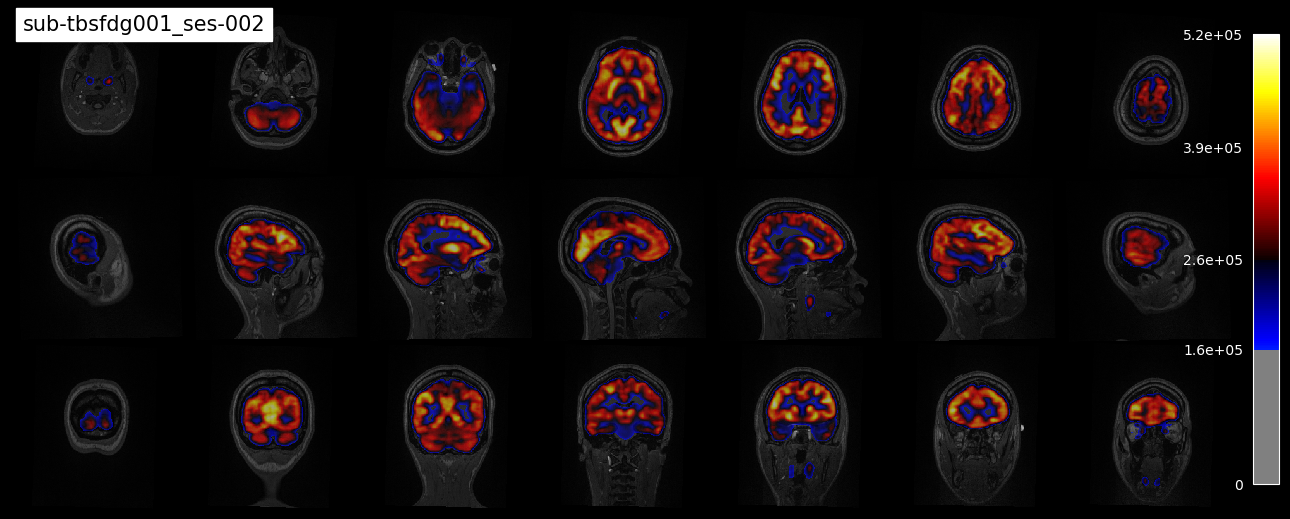

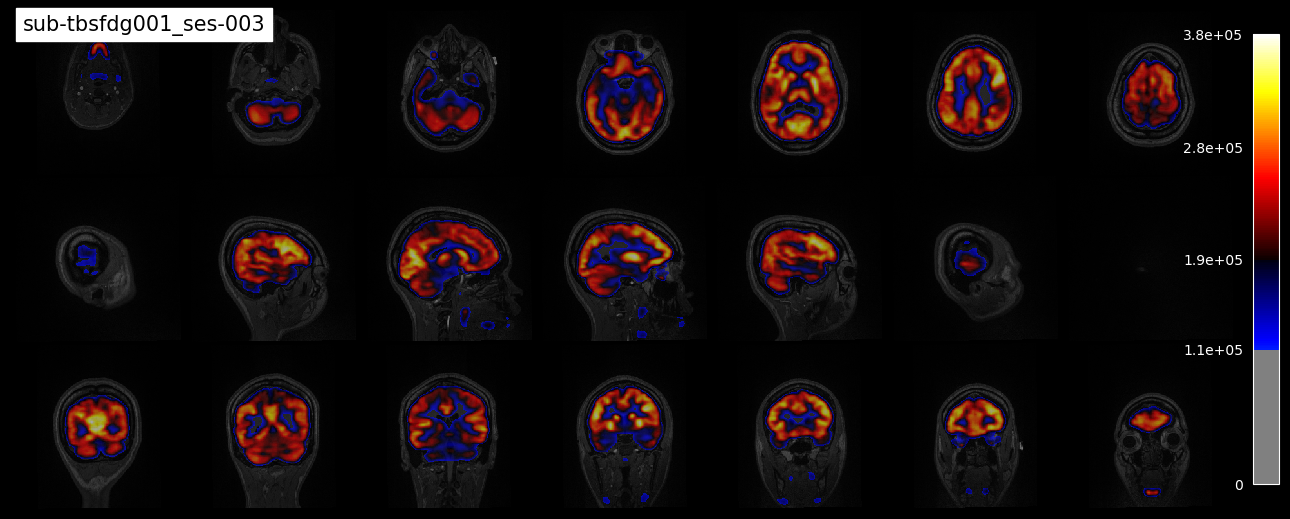

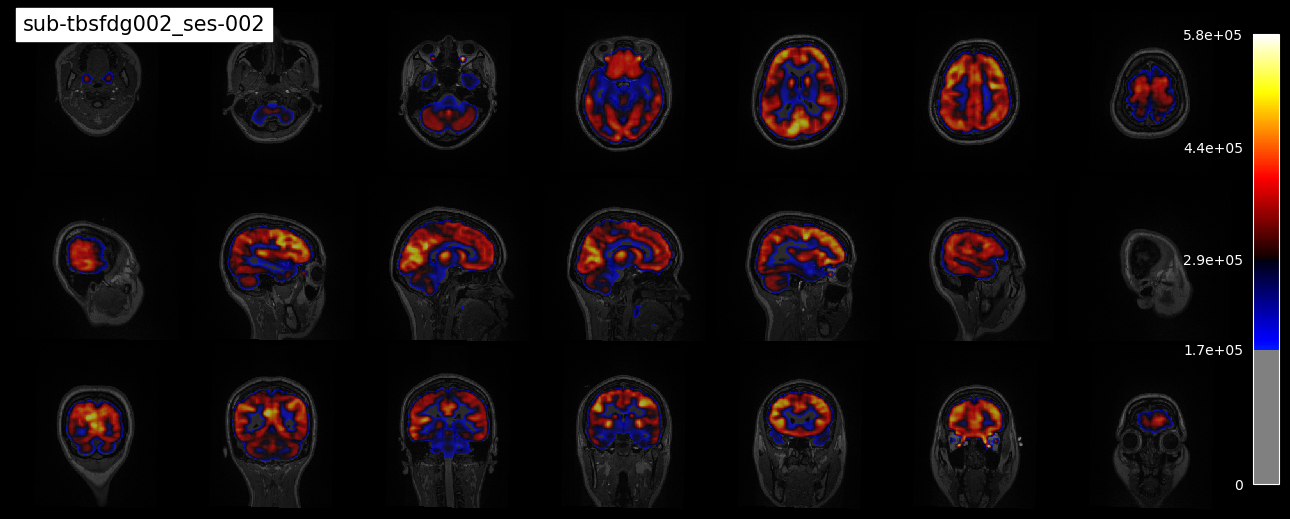

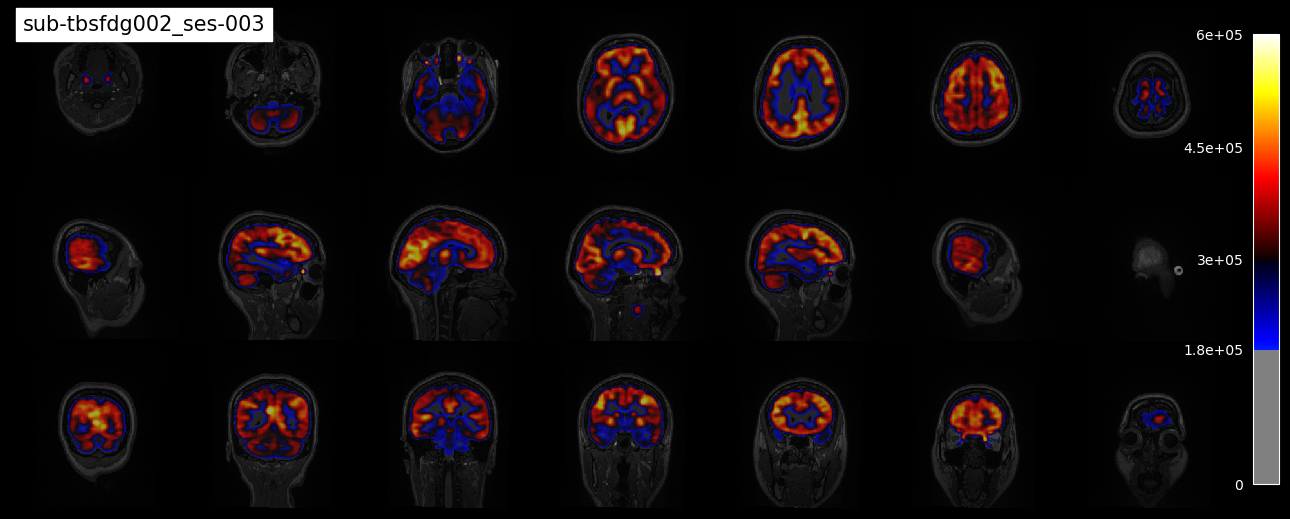

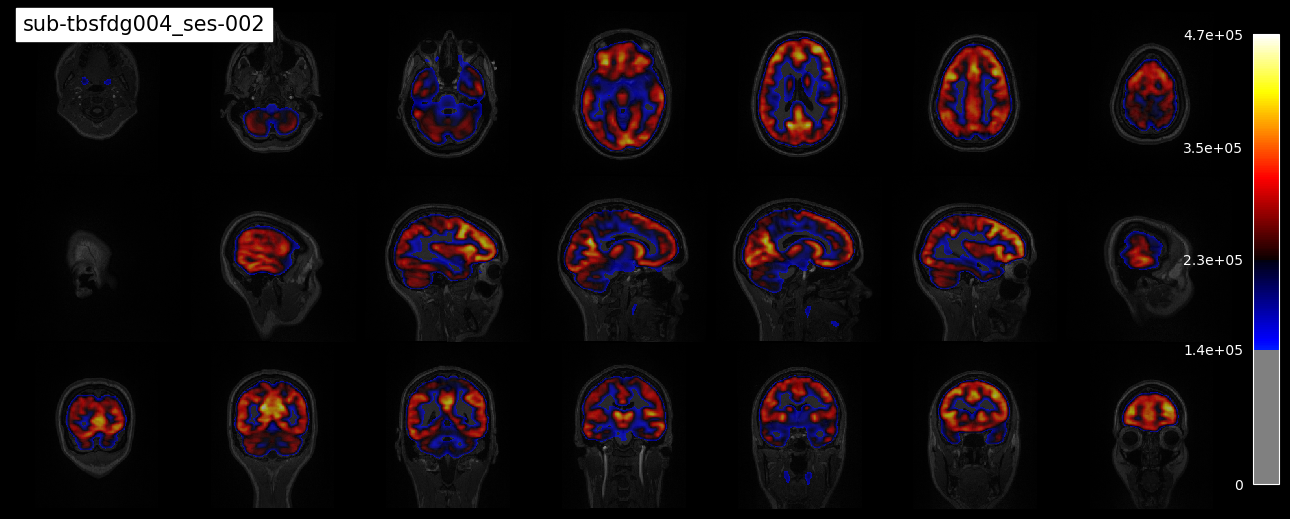

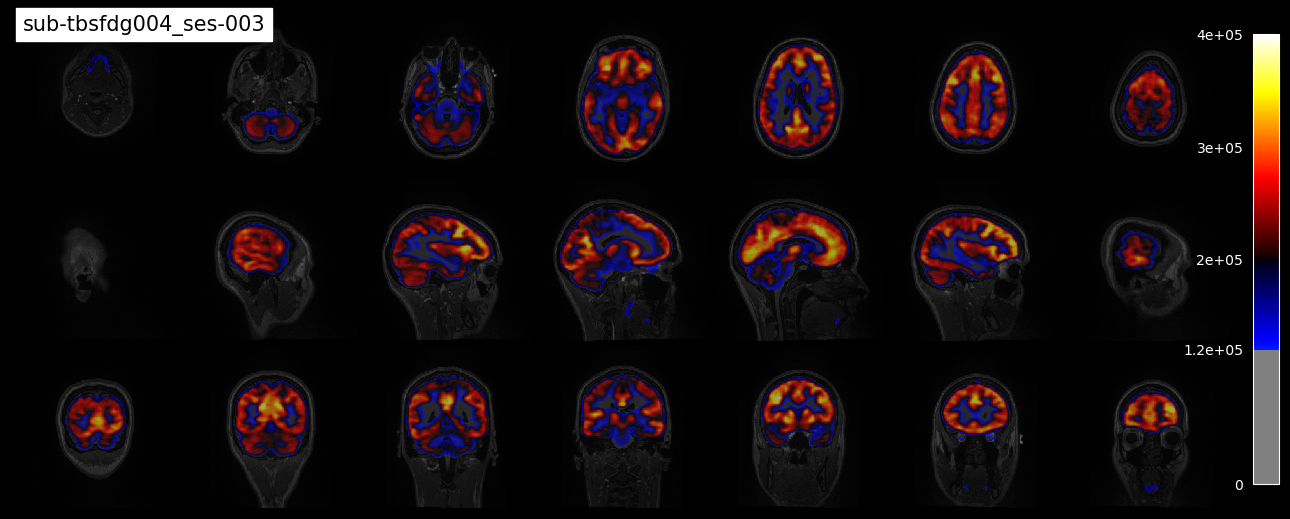

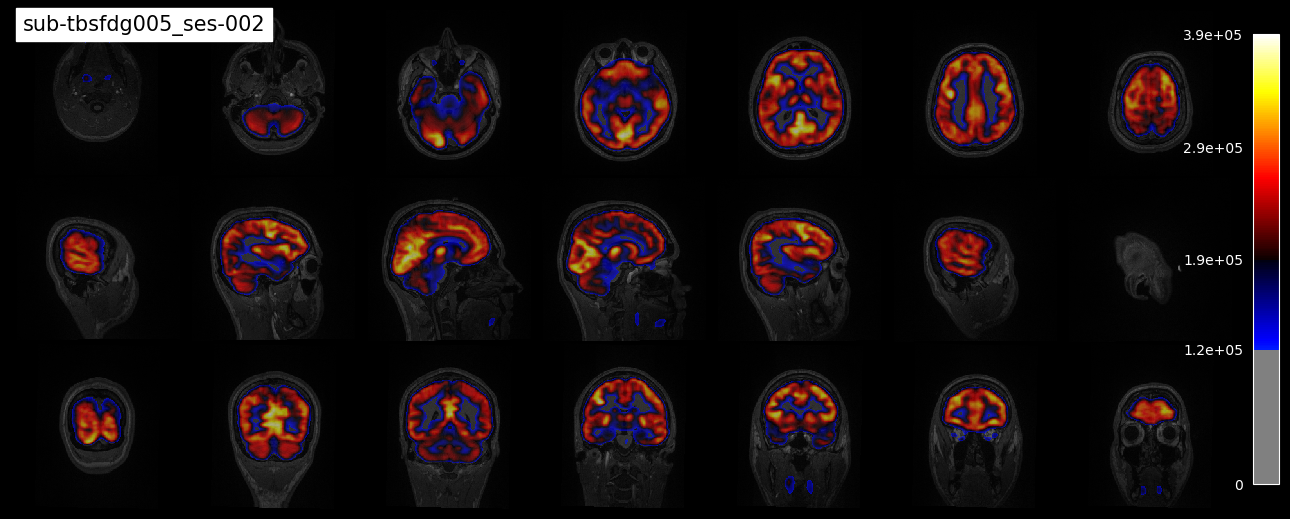

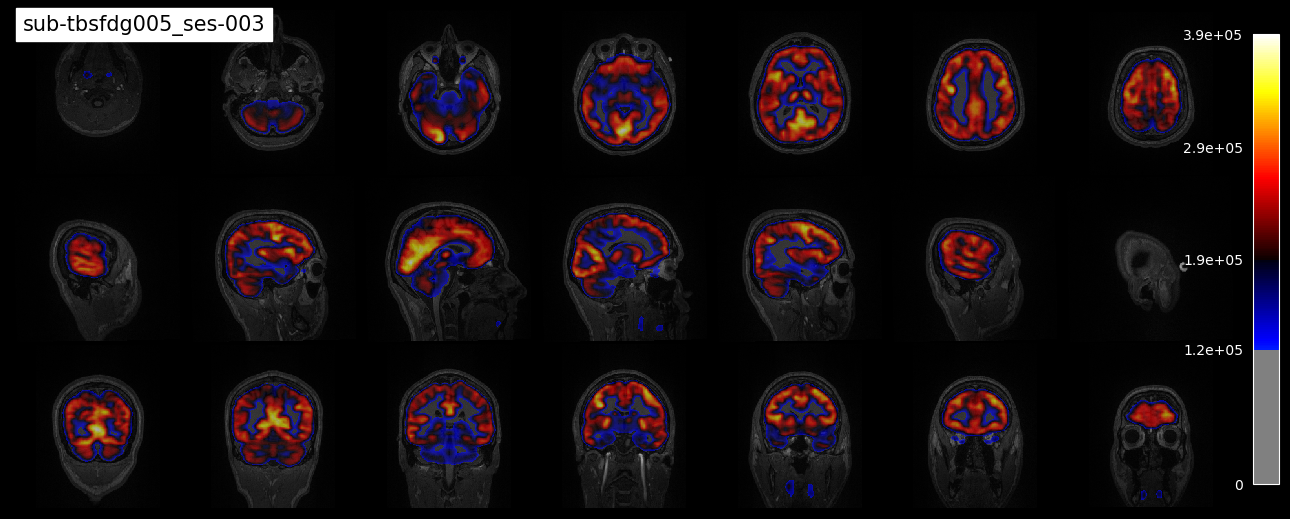

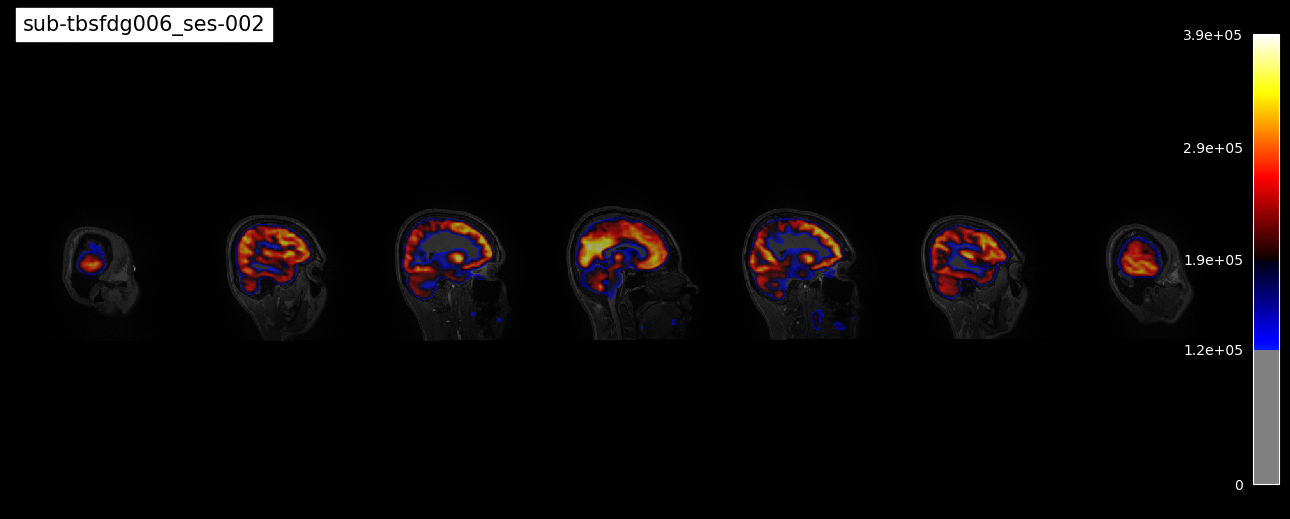

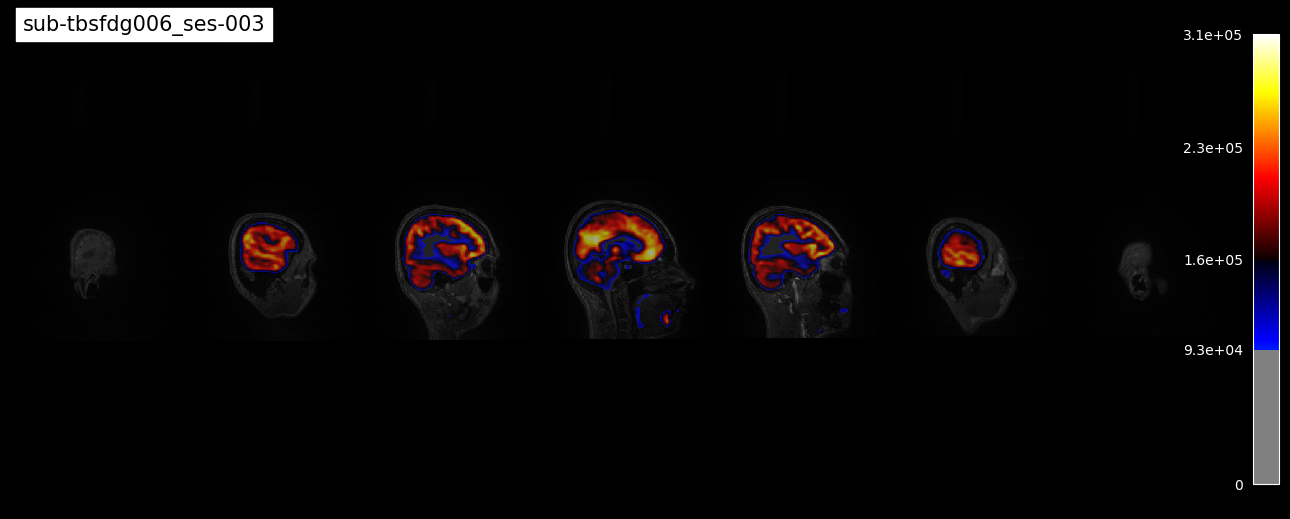

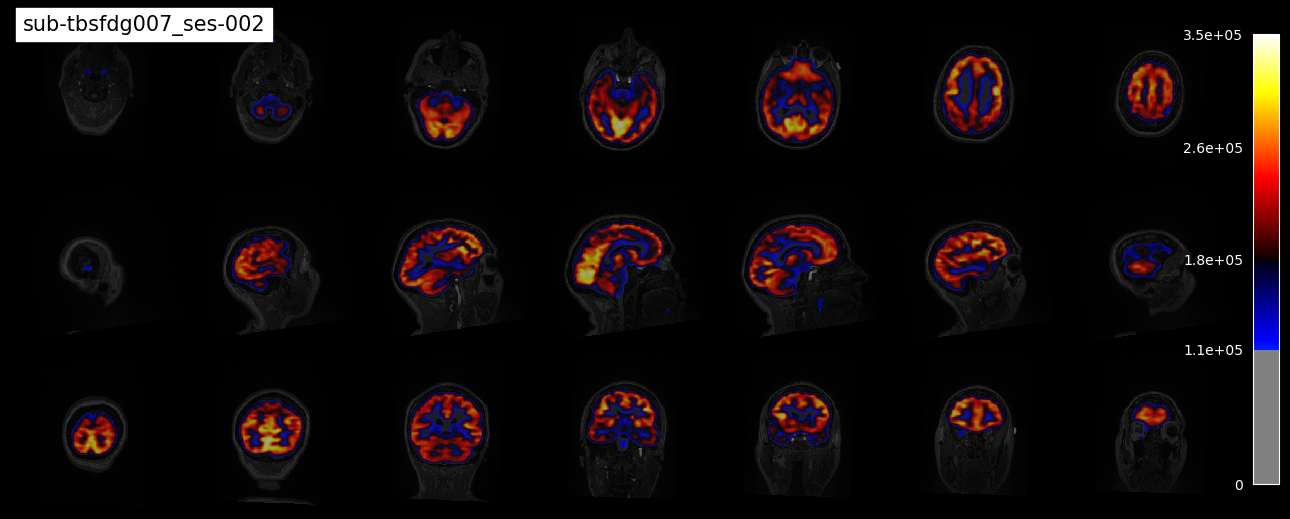

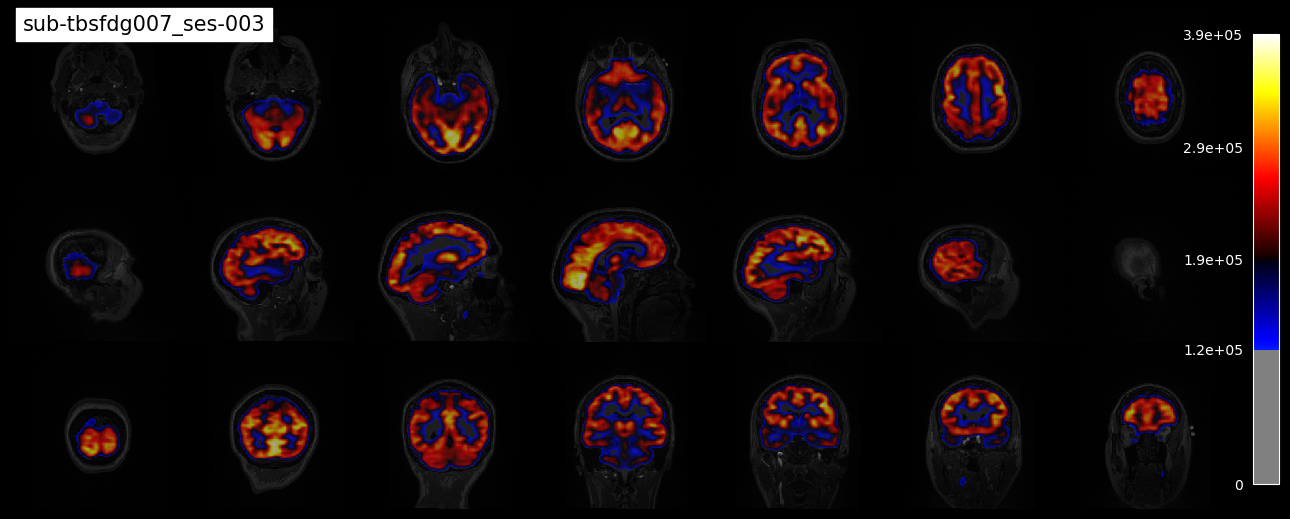

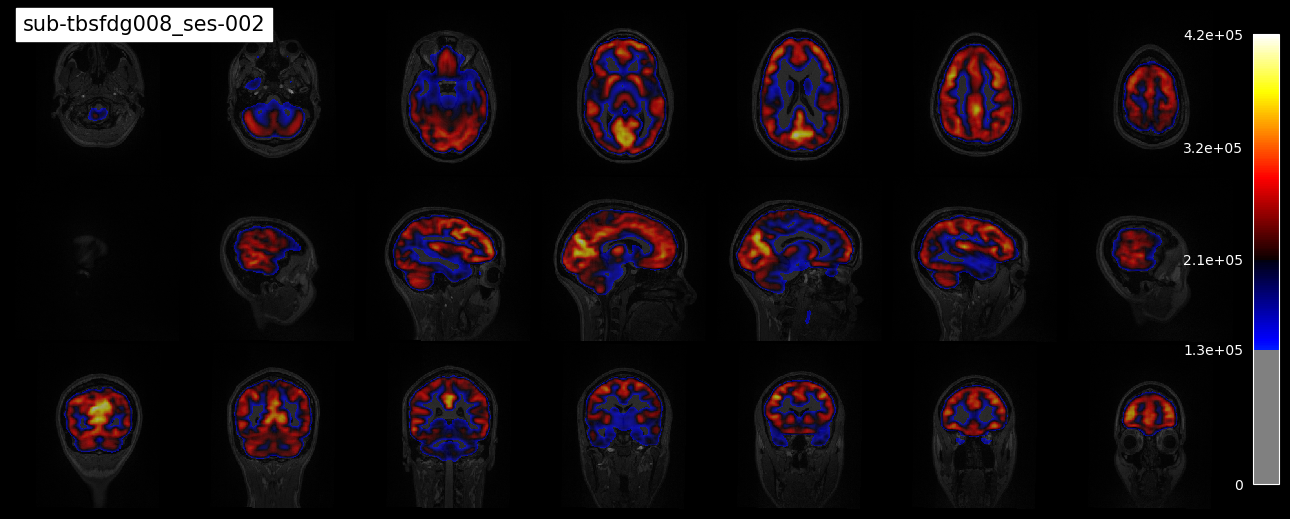

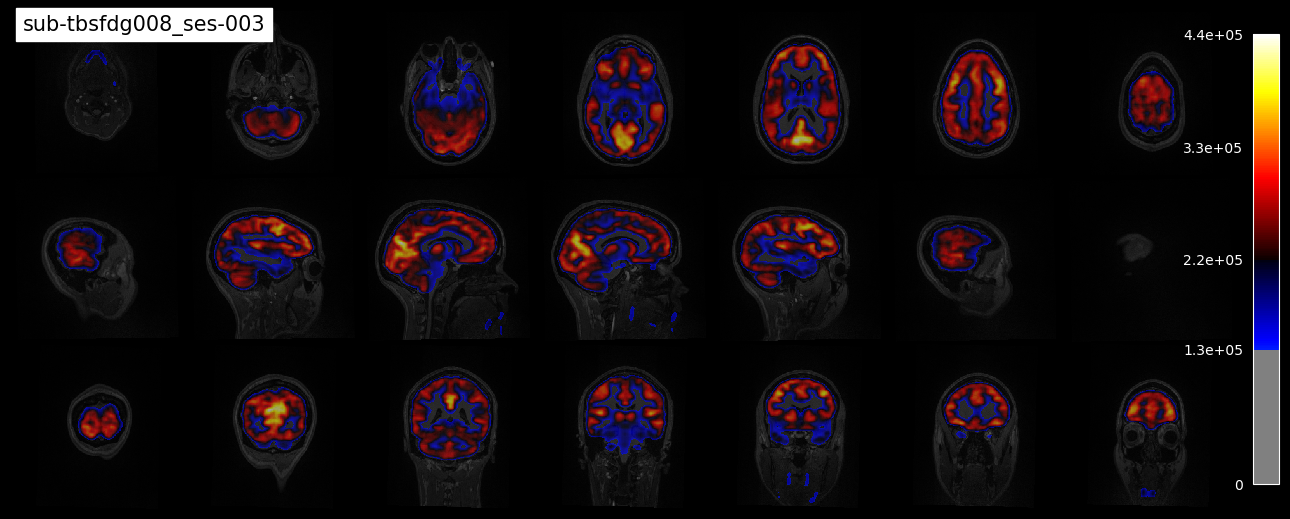

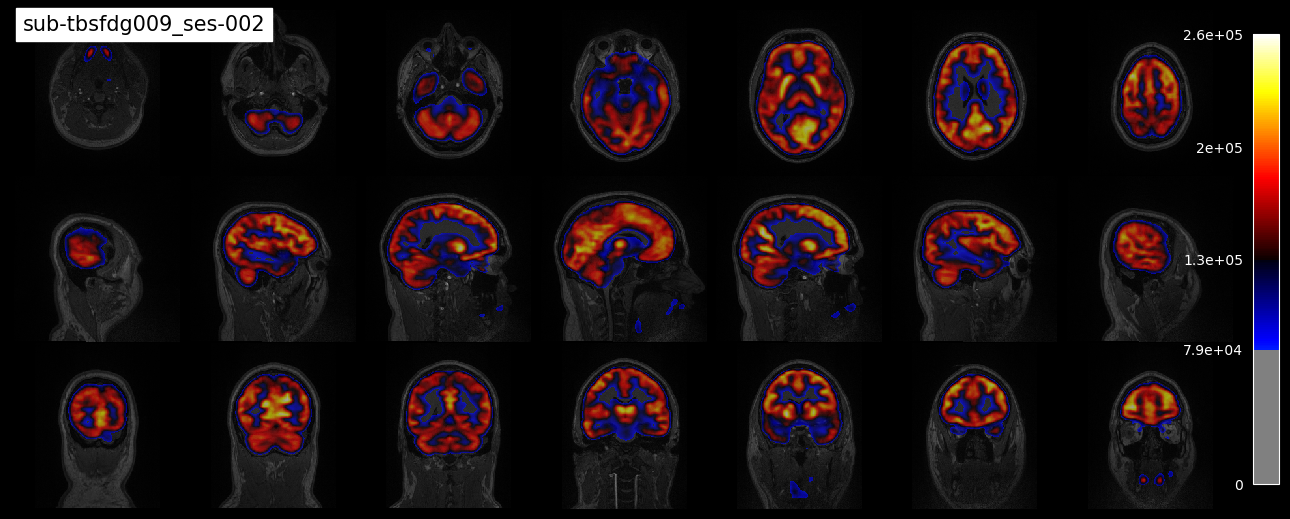

In [37]:

for subject in subjects:
    for ses in ['ses-002', 'ses-003']:
        if ses == 'ses-002':
            bdir = bids_dir2
            sdir = subjects_dir2
        else:
            bdir = bids_dir3
            sdir = subjects_dir3
        
        T1w_file = glob.glob(f'{bdir}/{subject}/{ses}/anat/{subject}_{ses}_desc-preproc_T1w.nii.gz')[0]
        PET_in_anat = glob.glob(f'{bdir}/{subject}/{ses}/pet/in-anat-{subject}-{ses}_pet.nii.gz')[0]
        #print(T1w_file)
        #print(PET_in_anat)
        
        PET = nb.load(PET_in_anat ).get_fdata()
        thr= 0.3 * np.max(PET)
        
        plotting_config = {
            "bg_img": T1w_file,
            "display_mode": "mosaic",
            "black_bg": True,
            
        }
        
        
        display = plot_stat_map(        
        PET_in_anat,
        threshold=thr,
        draw_cross=False,
        alpha = 0.4,
        annotate=False,
        title=f'{subject}_{ses}',
        **plotting_config 
            );
        
        plt.savefig(f'{output_dir}/PET_in_anat_{subject}.png', dpi=300, bbox_inches='tight')


In [25]:
T1w_file
PET_in_anat

'/home/lauri/Documents/TMS-FDG//derivatives/iter6s2/sub-tbsfdg009/ses-002/pet/in-anat-sub-tbsfdg009-ses-002_pet.nii.gz'